**Part B: Python + Pandas (15 marks, 40 min)**

Question 1: Load the file. Show the shape, the first 5 rows, and info().


In [2]:
from google.colab import files

uploaded = files.upload()

Saving Foodpanda Analysis Dataset.csv to Foodpanda Analysis Dataset.csv


In [3]:
import pandas as pd

df = pd.read_csv("Foodpanda Analysis Dataset.csv")

print("Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

Shape: (6000, 20)

First 5 Rows:


,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status
0,C5663,Male,Adult,Peshawar,1/14/2024,O9663,8/23/2023,McDonald's,Burger,Italian,5,1478.27,Cash,38,7/19/2025,238,Active,3,10/14/2024,Cancelled
1,C2831,Male,Adult,Multan,7/7/2024,O6831,8/23/2023,KFC,Burger,Italian,3,956.04,Wallet,24,11/25/2024,81,Active,2,8/21/2025,Delayed
2,C2851,Other,Senior,Multan,6/20/2025,O6851,8/23/2023,Pizza Hut,Fries,Italian,2,882.51,Cash,42,5/10/2025,82,Inactive,3,9/19/2024,Delayed
3,C1694,Female,Senior,Peshawar,9/5/2023,O5694,8/23/2023,Subway,Pizza,Dessert,4,231.30,Card,27,7/24/2025,45,Inactive,2,6/29/2025,Delayed
4,C4339,Other,Senior,Lahore,12/29/2023,O8339,8/24/2023,KFC,Sandwich,Dessert,1,1156.69,Cash,35,12/21/2024,418,Inactive,3,3/6/2025,Cancelled



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      6000 non-null   object 
 1   gender           6000 non-null   object 
 2   age              6000 non-null   object 
 3   city             6000 non-null   object 
 4   signup_date      6000 non-null   object 
 5   order_id         6000 non-null   object 
 6   order_date       6000 non-null   object 
 7   restaurant_name  6000 non-null   object 
 8   dish_name        6000 non-null   object 
 9   category         6000 non-null   object 
 10  quantity         6000 non-null   int64  
 11  price            6000 non-null   float64
 12  payment_method   6000 non-null   object 
 13  order_frequency  6000 non-null   int64  
 14  last_order_date  6000 non-null   object 
 15  loyalty_points   6000 non-null   int64  
 16  churned          6000 non-null   objec

Question 2: Find the missing values in each column. Handle them and remove duplicate rows. Add one
comment explaining why you chose that method.

In [4]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Handle missing values
# Median is used for numerical columns because it is less affected by outliers.
# Mode is used for categorical columns because it gives the most common value.


for col in df.select_dtypes(include="number").columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove duplicate rows
df = df.drop_duplicates()

print("\nShape after removing duplicates:")
print(df.shape)

Missing Values:
customer_id        0
gender             0
age                0
city               0
signup_date        0
order_id           0
order_date         0
restaurant_name    0
dish_name          0
category           0
quantity           0
price              0
payment_method     0
order_frequency    0
last_order_date    0
loyalty_points     0
churned            0
rating             0
rating_date        0
delivery_status    0
dtype: int64

Shape after removing duplicates:
(6000, 20)


Question 3: Create a new column total_sales = price × quantity.

In [5]:
df["total_sales"] = df["price"] * df["quantity"]

display(df.head())

,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,...,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status,total_sales
0,C5663,Male,Adult,Peshawar,1/14/2024,O9663,8/23/2023,McDonald's,Burger,Italian,...,1478.27,Cash,38,7/19/2025,238,Active,3,10/14/2024,Cancelled,7391.35
1,C2831,Male,Adult,Multan,7/7/2024,O6831,8/23/2023,KFC,Burger,Italian,...,956.04,Wallet,24,11/25/2024,81,Active,2,8/21/2025,Delayed,2868.12
2,C2851,Other,Senior,Multan,6/20/2025,O6851,8/23/2023,Pizza Hut,Fries,Italian,...,882.51,Cash,42,5/10/2025,82,Inactive,3,9/19/2024,Delayed,1765.02
3,C1694,Female,Senior,Peshawar,9/5/2023,O5694,8/23/2023,Subway,Pizza,Dessert,...,231.30,Card,27,7/24/2025,45,Inactive,2,6/29/2025,Delayed,925.20
4,C4339,Other,Senior,Lahore,12/29/2023,O8339,8/24/2023,KFC,Sandwich,Dessert,...,1156.69,Cash,35,12/21/2024,418,Inactive,3,3/6/2025,Cancelled,1156.69


Question 4: Create a new column total_sales = price × quantity.

In [6]:
top_3_dishes = (
    df.groupby("dish_name")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
)

print("Top 3 Best-Selling Dishes:")
display(top_3_dishes)

Top 3 Best-Selling Dishes:


,total_sales
dish_name,
Pasta,3078850.36
Sandwich,2966591.11
Pizza,2782227.05


In [7]:
average_rating = df.groupby("category")["rating"].mean()

print("Average Rating Per Category:")
display(average_rating)

Average Rating Per Category:


,rating
category,
Chinese,3.006678
Continental,2.997523
Dessert,3.050309
Fast Food,2.954992
Italian,2.978964


Question 5:
Write a function rating_label(r) that returns "Good" (rating 4-5), "Average" (rating 3) or "Poor"
(rating 1-2). Apply it to the rating column and save the result in a new column.

In [8]:
def rating_label(r):
    if r >= 4:
        return "Good"
    elif r == 3:
        return "Average"
    else:
        return "Poor"

df["rating_label"] = df["rating"].apply(rating_label)

display(df[["rating", "rating_label"]].head(10))

,rating,rating_label
0,3,Average
1,2,Poor
2,3,Average
3,2,Poor
4,3,Average
5,4,Good
6,1,Poor
7,2,Poor
8,4,Good
9,3,Average


**Part C: Visualization + Statistics (10 marks, 25 min)**

Question 1: Draw a bar chart of total sales by category, with a title and axis labels.

/tmp/ipykernel_7101/2470117837.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


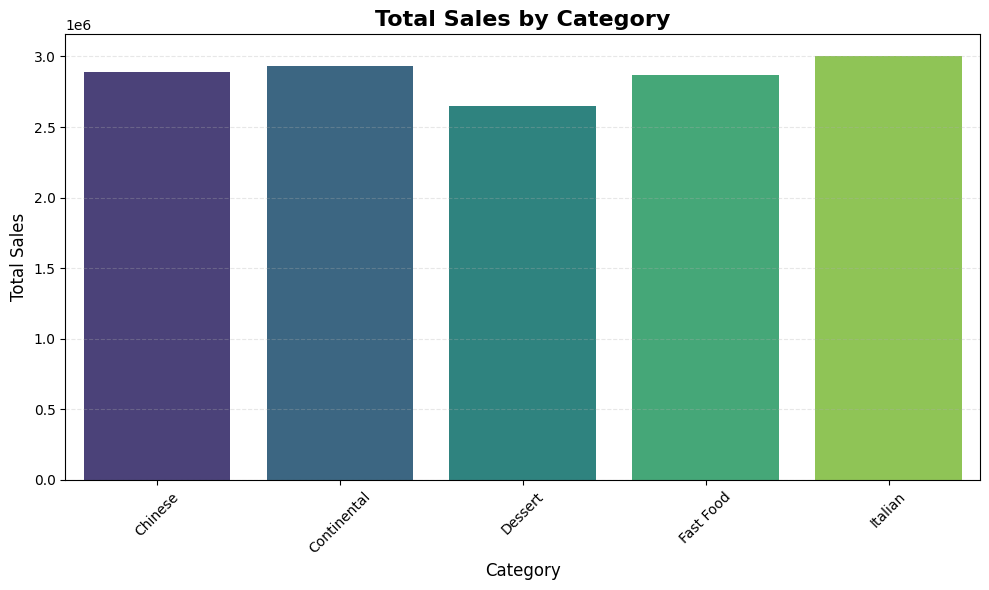

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total sales by category
sales_by_category = df.groupby("category")["total_sales"].sum()

# Create bar chart
plt.figure(figsize=(10, 6))

sns.barplot(
    x=sales_by_category.index,
    y=sales_by_category.values,
    palette="viridis"
)

plt.title("Total Sales by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

Question 2: Draw a histogram of price, with a title and axis labels.

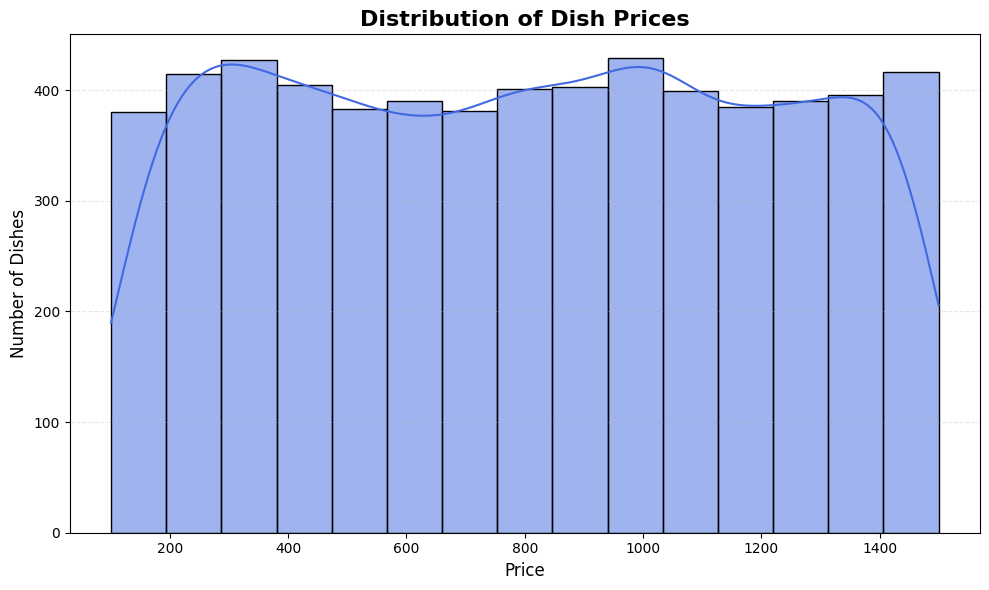

In [10]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["price"],
    bins=15,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Dish Prices", fontsize=16, fontweight="bold")
plt.xlabel("Price", fontsize=12)
plt.ylabel("Number of Dishes", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

Question 3: Calculate the mean, median and standard deviation of total_sales. Write 2 sentences
interpreting them.

In [11]:
# Calculate statistics
mean_sales = df["total_sales"].mean()
median_sales = df["total_sales"].median()
std_sales = df["total_sales"].std()

print("Mean Total Sales:", mean_sales)
print("Median Total Sales:", median_sales)
print("Standard Deviation:", std_sales)

Mean Total Sales: 2390.6520133333333
Median Total Sales: 1901.5749999999998
Standard Deviation: 1754.874758108934


The average total sales is about 2390.65, while the median is about 1901.57, showing that some higher sales values are increasing the average.

The standard deviation is about 1754.87, which means total sales have a relatively large variation around the average.

Question 4: Draw a scatter plot of price vs total_sales. Write one sentence about what you see.

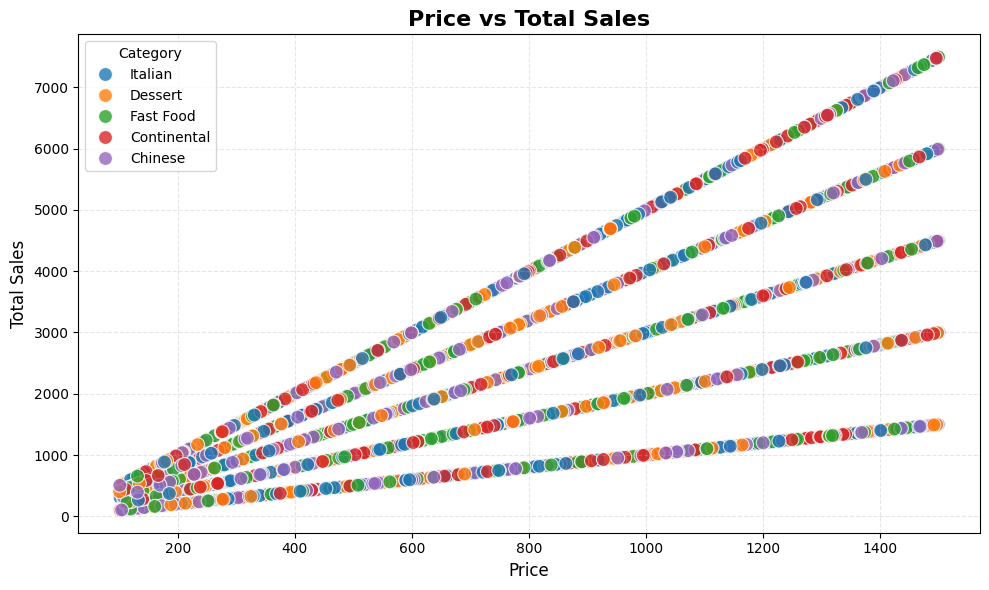

In [12]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="price",
    y="total_sales",
    hue="category",
    s=100,
    alpha=0.8
)

plt.title("Price vs Total Sales", fontsize=16, fontweight="bold")
plt.xlabel("Price", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(title="Category")

plt.tight_layout()
plt.show()

The scatter plot shows a positive relationship between price and total sales, because total sales generally increase as price increases.

**Part D: Mini ML**

Question 1: Use Linear Regression to predict total_sales from price, quantity and order_frequency. Do the
train/test split (80/20, random_state=42), fit the model and predict on the test set.

In [14]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Select input features
X = df[["price", "quantity", "order_frequency"]]

# Select target variable
y = df["total_sales"]

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict total_sales on test data
y_pred = model.predict(X_test)

# Show some predictions
print("Predicted Total Sales:")
print(y_pred[:10])

Predicted Total Sales:
[3176.31541385 2253.41771899 -122.78192297 3866.60262414 -511.89568475
 1594.12351761  658.02883672 1939.17018571 1252.84237464 1537.37824329]


Question 2: Report R2 or MAE on the test set.

In [15]:
from sklearn.metrics import r2_score

# Calculate R2 score
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.8935614191167981


Question 3: In 3 lines, explain in plain language what your result means.

The model explains about 89.36% of the variation in total sales.

This means price, quantity, and order frequency are useful for predicting total sales.

The model has a fairly strong prediction performance because the R² score is close to 1.